# LiDAR-to-Spatial-Audio Navigation Aid — System Prototype

This notebook presents the implemented components of the navigation aid prototype for visually impaired users.

Sections covered:
- Loading and preloading recorded depth frames from iPhone LiDAR (.npy format)
- Loading HRTF impulse responses from a SOFA file and building a KDTree for direction lookup
- Visualising depth frames alongside RGB footage with false-colour mapping
- Generating spatialized audio pings using pink noise, bandpass filtering, and HRTF convolution
- Mapping depth image pixels to azimuth/elevation angles using camera intrinsics
- Extracting horizontal scan profiles with elevation-based floor filtering
- Building time-sequenced stereo sweeps from scan point arrays
- Synchronised sweep playback with inline depth visualisation
- Frame-by-frame depth video playback with sweep overlay (sequential prototype)
- Semi real-time simulation using concurrent video and audio threads with crossfade blending
- Proposed next steps: LiDAR-based dynamic hazard tracking and RGB peripheral detection


The notebook is structured to be run top-to-bottom; each section builds on the outputs of the previous one.

## 1. Dependencies

The following libraries are used for numerical processing, visualization, HRTF handling, and audio playback.

In [2]:
# Numerical / signal processing
import numpy as np
from scipy.spatial import KDTree
from scipy.signal import fftconvolve, butter, sosfilt

# Audio
import sounddevice as sd
import sofar as sf

# Image / visualisation
import cv2
import matplotlib.pyplot as plt

# Standard library
import os, json, time, threading

## 2. Input files

This section defines the paths for:
- the recorded depth frames
- the metadata file from the recording
- the SOFA file containing HRTF impulse responses

In [3]:
# Directory of stored depth folder (You must change these)
DEPTH_DIR = r'D:\GradProj\2026-03-10--13-55-34_extracted\depth'
RGB_DIR = r'D:\GradProj\2026-03-10--13-55-34_extracted\rgb'
META = r'D:\GradProj\2026-03-10--13-55-34_extracted\metadata.json'
SOFA = sf.read_sofa("D:\GradProj\H10_HRIR_SOFA\H10_48K_24bit_256tap_FIR_SOFA.sofa")

SOFA file contained custom entries
----------------------------------
GLOBAL_NCProperties


## 3. Load recorded depth frames

The depth recording consists of `.npy` files, one per frame.
The function below:
- finds all frame files
- reads the first frame to determine image dimensions
- preallocates a NumPy array for efficiency
- loads all depth frames into memory

Preloading depth improves playback and analysis speed during later steps.

*NOTE:* We don't preload the RGB frames becuase it will make your RAM cry

In [4]:
# Function to load depth, just run this block
def load_depth(depth_dir):
    
    files = sorted([f for f in os.listdir(depth_dir) if f.endswith('.npy')])
    n_frames = len(files)

    sample = np.load(os.path.join(depth_dir, files[0]))
    h, w = sample.shape

    depths = np.zeros((n_frames, h, w), dtype=np.float32)

    for i, fname in enumerate(files):
        depths[i] = np.load(os.path.join(depth_dir, fname))
        if i % 200 == 0:
            print(f"  {i}/{n_frames}")
            
    return depths, n_frames

In [5]:
# Loading depths
depths, frames = load_depth(DEPTH_DIR)

  0/1849
  200/1849
  400/1849
  600/1849
  800/1849
  1000/1849
  1200/1849
  1400/1849
  1600/1849
  1800/1849


### Verify loaded data

This section prints basic information about the loaded depth recording as well as a small visualization to confirm that the frames were read correctly.

In [6]:
print("Depth array shape:", depths.shape)
print("Number of frames:", frames)
print("First frame dtype:", depths[0].dtype)
print("Min depth in first frame:", np.nanmin(depths[0]))
print("Max depth in first frame:", np.nanmax(depths[0]))

Depth array shape: (1849, 192, 256)
Number of frames: 1849
First frame dtype: float32
Min depth in first frame: 0.8105469
Max depth in first frame: 3.0859375


C:\Users\ahmad\AppData\Local\Temp\ipykernel_17352\3735136136.py:11: RuntimeWarning: invalid value encountered in cast
  disp = np.interp(d, (mn, mx), (0, 255)).astype(np.uint8)


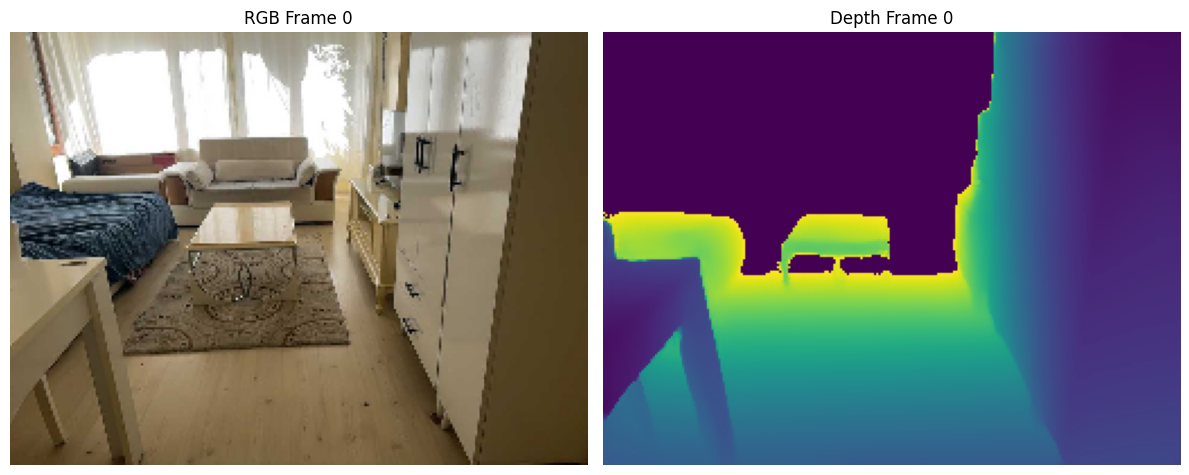

In [7]:
i = 0 # Pick frame

# Depth frame
d = depths[i]
mn = np.nanmin(d)
mx = np.nanmax(d)

if np.isclose(mn, mx):
    disp = np.zeros_like(d, dtype=np.uint8)
else:
    disp = np.interp(d, (mn, mx), (0, 255)).astype(np.uint8)

d_color = cv2.applyColorMap(disp, cv2.COLORMAP_VIRIDIS)

# RGB Frame
rgb_path = os.path.join(RGB_DIR, f"{i:05d}.jpg")
rgb_frame = cv2.imread(rgb_path)
rgb_frame = cv2.cvtColor(rgb_frame, cv2.COLOR_BGR2RGB)
rgb_frame = cv2.resize(rgb_frame, (d_color.shape[1], d_color.shape[0])) # Resize

# Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb_frame)
plt.title(f"RGB Frame {i}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(d_color, cv2.COLOR_BGR2RGB))
plt.title(f"Depth Frame {i}")
plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Verify HRTF (SOFA) data and spatial audio

This section demonstrates how spatial audio is generated using HRTF data.

The SOFA file contains Head-Related Impulse Responses (HRIRs), which encode how sound arriving from a specific direction is filtered by the human head and ears.

By convolving a sound signal with these impulse responses:
- the sound can be perceived as coming from a specific direction
- spatial awareness can be simulated using headphones

In this section:
- we inspect the SOFA dataset
- we select directions from it
- we generate spatialized "ping" sounds
- the user can test how direction changes the perceived sound location
  
**Note:** Headphones are required

In [8]:
print("SOFA Data_IR shape:", SOFA.Data_IR.shape)
print("Number of directions:", SOFA.Data_IR.shape[0])
print("Samples per IR:", SOFA.Data_IR.shape[2])

SOFA Data_IR shape: (2114, 2, 256)
Number of directions: 2114
Samples per IR: 256


The SOFA dataset stores:
- one impulse response per direction
- two channels per direction (left ear, right ear)

Shape meaning:
<div style="float: left; width: 100%;">

| Axis | Size | Meaning |
| :--- | :--- | :--- |
| M | number of directions | one IR per direction |
| 2 | channels | left ear / right ear |
| N | samples per IR | impulse response length |

</div>


### KDTree for HRTF Direction Lookup

The SOFA dataset contains impulse responses measured at many discrete directions,
each defined by:
- `azimuth (horizontal angle)`
- `elevation (vertical angle)`

However, when generating spatial audio, we may request a direction that does not exactly exist in the dataset.

To handle this, we use a KDTree:
- it stores all available directions as points in a 2D space (azimuth, elevation)
- given a requested direction, it efficiently finds the *closest available direction* using Euclidean distance in the (azimuth, elevation) plane

This allows us to approximate any direction using the nearest measured HRTF.

#### Effect of weighting

Weights allow control over how "important" each dimension is when selecting the nearest HRTF.

- Increasing azimuth weight → improves left/right accuracy
- Decreasing elevation weight → reduces sensitivity to vertical differences

This is useful because:
- human perception is generally more sensitive to horizontal localization
- the system primarily operates in a horizontal scanning mode

Example:
w = [1.0, 0.3] prioritizes azimuth over elevation

In [9]:
azimuths = SOFA.SourcePosition[:, 0]
elevations = SOFA.SourcePosition[:, 1]
w = [1.0, 1.0] # You can change and play around with these weights
points = np.column_stack([w[0] * azimuths, w[1] * elevations])
# Create the KD Tree
tree = KDTree(points)

In [10]:
print("Azimuth range:")
print(f"Min:{np.min(azimuths)}°")
print(f"Max:{np.max(azimuths)}°")

print("\nElevation range:")
print(f"Min: {np.min(elevations)}°")
print(f"Max: {np.max(elevations)}°")

print("\nUnique azimuth samples (first 10):")
print(np.unique(azimuths)[:10])

print("\nUnique elevation samples:")
print(np.unique(elevations))

Azimuth range:
Min:0.0°
Max:355.0°

Elevation range:
Min: -90.0°
Max: 90.0°

Unique azimuth samples (first 10):
[ 0.   5.  10.  12.8 13.3 15.  17.1 18.  18.4 19. ]

Unique elevation samples:
[-90.  -81.  -75.  -64.8 -60.  -54.  -45.  -35.3 -30.  -25.  -17.5 -15.
   0.   15.   17.5  25.   30.   35.3  45.   54.   60.   64.8  75.   90. ]


In [11]:
# Test direction (you can change this)
test_az = 30.0
test_el = 10.0

# Query KDTree
dist, idx = tree.query([w[0] * test_az, w[1] * test_el])

# Retrieved direction from SOFA
nearest_az = azimuths[idx]
nearest_el = elevations[idx]

print("\nRequested direction:")
print(f"  Azimuth: {test_az}°, Elevation: {test_el}°")

print("\nNearest HRTF direction:")
print(f"  Azimuth: {nearest_az}°, Elevation: {nearest_el}°")

print("\nDistance (in weighted space):", dist)


Requested direction:
  Azimuth: 30.0°, Elevation: 10.0°

Nearest HRTF direction:
  Azimuth: 30.0°, Elevation: 15.0°

Distance (in weighted space): 5.0


### Generate a spatialized ping 

The function below generates a stereo ping that simulates a sound coming from a specified spatial direction. 

**Inputs:** 
- `azimuth` 
- `elevation` 
- `distance` 

**Processing steps:**
1. **Convert the azimuth** into the coordinate convention used by the SOFA dataset. (0-355)
2. **Find the nearest available HRTF direction** using the KDTree.
3. **Generate a short ping signal.**
4. **Filter and smooth** the ping.
5. **Convolve the ping** with the left and right HRIRs.
6. **Scale the output based on distance**  
   The gain is calculated using the following formula:
   $$
   \begin{flalign}
   &\text{gain} = G_{min} + (G_{max} - G_{min}) \left(1 - \frac{d}{d_{max}}\right)^{amp}&& \\
   \end{flalign}
   $$  
   *You can tweak this formula to change the sensitivity as you like.*

The result is a stereo signal that can be played through headphones to perceive spatial direction. 

**NOTE:** Since the SADIE II datasets has azimuths in the range 0–355 and the iPhone FOV is in the range -35 to 35, we must map these values using modular arithmetic.


#### Pink noise generation

Instead of using white noise, this system uses *pink noise* to generate the base signal for spatial pings.

White noise has equal energy across all frequencies and can sound harsh and unnatural.
Pink noise, by contrast, has energy that decreases with frequency (∝ 1/√f), making it 
perceptually more balanced and better matched to human auditory sensitivity.

The function below generates pink noise by:
1. creating white noise
2. transforming it into the frequency domain
3. scaling frequencies to follow a 1/√f distribution
4. transforming back to the time domain

In [12]:
def pink_noise(n):
    
    # white noise
    x = np.random.randn(n)

    # go to frequency domain with fast fourier transform
    X = np.fft.rfft(x)
    
    freqs = np.fft.rfftfreq(n)
    freqs[0] = 1.0  # avoid division by zero

    # apply 1/sqrt(f) scaling
    X /= np.sqrt(freqs)

    # back to time domain (inverse fourier transform)
    y = np.fft.irfft(X, n)

    return y.astype(np.float32)

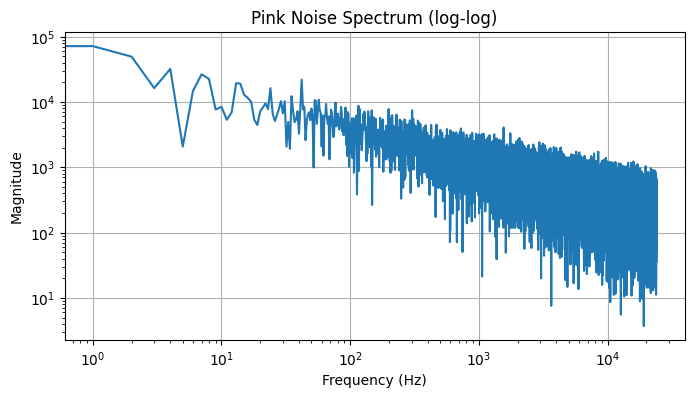

In [13]:
# visualize frequency content
n = 48000
y = pink_noise(n)

Y = np.abs(np.fft.rfft(y))
freqs = np.fft.rfftfreq(n, 1/48000)

plt.figure(figsize=(8,4))
plt.plot(freqs, Y)
plt.xscale("log")
plt.yscale("log")
plt.title("Pink Noise Spectrum (log-log)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid()
plt.show()

The downward slope confirms that higher frequencies have lower energy, characteristic of pink noise.

In [14]:
def make_spatial_ping(azimuth, elevation, distance, sofa, tree,
                      sample_rate=48000, max_range=3.0, dur=0.5,
                      bandpass=[1200, 6000], amp=6):

    # find nearest HRIR
    az_sadie = (-azimuth) % 360 # This is needed to convert from (-35,35) -> (0, 355)
    _, idx = tree.query([az_sadie, elevation])

    # HRIR
    hrir_left = sofa.Data_IR[idx, 0, :]   # left channel
    hrir_right = sofa.Data_IR[idx, 1, :]  # right channel

    # create ping
    n = max(1, int(dur * sample_rate))
    ping = pink_noise(n)

    # bandpass filter
    sos = butter(4, bandpass, btype="bandpass", fs=sample_rate, output="sos")
    ping = sosfilt(sos, ping).astype(np.float32)

    # hanning window for smoothing
    ping *= np.hanning(n).astype(np.float32)
    ping /= (np.max(np.abs(ping)) + 1e-8) # avoid division by zero.

    # Convolution
    left = fftconvolve(ping, hrir_left, mode="full").astype(np.float32)
    right = fftconvolve(ping, hrir_right, mode="full").astype(np.float32)

    # Distance-Gain calculation
    d = np.clip(distance, 0.0, max_range)
    min_gain, max_gain = 0.08, 1.0
    gain = min_gain + (max_gain - min_gain) * (1 - d / max_range) ** amp
    left *= gain
    right *= gain

    stereo = np.column_stack((left, right)).astype(np.float32)

    return stereo

#### Listening test

The following example generates a ping from a chosen direction and distance.

When played through headphones:
- negative azimuth values should be perceived from the left
- positive azimuth values should be perceived from the right
- larger distances should sound quieter than smaller distances

In [16]:
audio = make_spatial_ping(
    azimuth=35,
    elevation=-25,
    distance=2,
    sofa=SOFA,
    tree=tree
)

sd.play(audio, 48000)
sd.wait()

#### Future user customization

A future version of the system should allow user-specific customization of the spatial audio parameters.

This is important because different users may perceive spatial cues differently depending on:
- ear shape
- head-related acoustic differences
- sensitivity to certain frequency ranges
- personal comfort with different ping durations or repetition rates

Possible customization options include:
- selecting between different HRTF datasets (KEMAR MIT, LISTEN, SADIE II, etc.)
- adjusting the ping frequency range
- changing ping duration
- changing loudness scaling with distance
- tuning the balance between directional clarity and listening comfort

This is a future development point and is not yet implemented in the current prototype.

## 5. Sweep-based sonification with HRTF

This section demonstrates how a 2D depth frame is converted into a sequence of spatial audio cues.

The approach is based on a left-to-right sweep:
- the image is scanned column by column
- each column represents a viewing direction
- the nearest obstacle in that column is selected
- that obstacle is converted into a spatialized audio ping

This creates a temporal sequence of sounds that represent the spatial structure of the scene.

### Mapping image pixels to viewing angles

Each pixel in the depth image corresponds to a specific viewing direction.

Using the camera intrinsic parameters obtained from metadata file:
- \( f_x, f_y \): focal lengths
- \( c_x, c_y \): optical center

we can convert pixel coordinates into angles.

For a pixel at column \(u\) and row \(v\):

$$
\begin{flalign}
&\text{azimuth}(u) = \tan^{-1}\left(\frac{u - c_x}{f_x}\right)&& \\
&\text{elevation}(v) = \tan^{-1}\left(\frac{v - c_y}{f_y}\right)&&
\end{flalign}
$$


This gives:
- azimuth → horizontal direction (left/right)
- elevation → vertical direction (up/down)

These angles describe the direction of each pixel relative to the camera.

In [17]:
def get_camera_data(f):

    with open(f) as f:
        meta = json.load(f)
    
    coeffs = np.array(meta["perFrameIntrinsicCoeffs"])
    dw , dh = meta["dw"], meta["dh"]
    w, h = meta["w"], meta["h"]
    fx, fy, cx, cy = coeffs.mean(axis=0)

    # Focal Points (Scaled)
    fx_d = fx * (dw/w)
    fy_d = fy * (dh/h)
    # Cam Center (Scaled)
    cx_d = cx * (dw/w)
    cy_d = cy * (dh/h)
    
    return fx_d, fy_d, cx_d, cy_d
    
def read_pixels(d, fx_d, fy_d, cx_d, cy_d):

    h, w = d.shape
    u = np.arange(w)
    v = np.arange(h)

    azimuths = np.arctan((u - cx_d) / fx_d)
    elevations = -np.arctan((v - cy_d) / fy_d) # Negated because the depth video was recorded in landscape mode, which reverses the elevation polarity.

    return azimuths, elevations

In [18]:
# Camera intrinsics — computed once from metadata and reused throughout.
# These are fixed for this recording session and do not change frame-to-frame.
FX, FY, CX, CY = get_camera_data(META)
AZI, ELV = read_pixels(d, FX, FY, CX, CY)

print(f"Focal lengths : fx={FX:.4f}, fy={FY:.4f}")
print(f"Optical centre: cx={CX:.4f}, cy={CY:.4f}")

Focal lengths : fx=178.4229, fy=178.4229
Optical centre: cx=127.7368, cy=94.8329


### Scan strategy

To reduce the 2D depth frame into a manageable representation:

- a subset of image columns is selected
- for each column:
  - all depth values are examined
  - the nearest valid depth value is selected
  - the corresponding pixel location is identified

From this pixel:
- column index → azimuth
- row index → elevation
- depth value → distance

This produces a set of spatial samples across the field of view.

**NOTE:** A naive scan would select the nearest depth value in each column. However, this often causes the floor to dominate the result, since the ground plane is usually one of the closest visible surfaces. To reduce this effect, elevation-based filtering is used.

In [19]:
def extract_scan_points(d, azimuths=AZI, elevations=ELV, scan_cols=None, max_range=3.0, min_elevation_deg=-15.0):

    h, w = d.shape

    if scan_cols is None:
        scan_cols = np.linspace(0, w - 1, 32, dtype=int) # Scans 32 evenly spaced cols

    min_elevation_rad = np.deg2rad(min_elevation_deg)

    near_az = []
    near_el = []
    near_dist = []
    sel_cols = []
    sel_rows = []

    elevation_valid = elevations >= min_elevation_rad

    for u in scan_cols:
        column = d[:, u]

        valid = (np.isfinite(column) & (column > 0) & (column <= max_range) & elevation_valid ) # boolean mask to filter valid pixels

        if not np.any(valid):
            continue

        valid_rows = np.where(valid)[0]
        v_local = np.argmin(column[valid])
        v = valid_rows[v_local]

        near_az.append(np.degrees(azimuths[u]))
        near_el.append(np.degrees(elevations[v]))
        near_dist.append(float(d[v, u]))
        sel_cols.append(u)
        sel_rows.append(v)

    return np.array(near_az), np.array(near_el), np.array(near_dist), np.array(sel_cols), np.array(sel_rows)

#### Verification of extracted scan points

The following output shows a few extracted scan samples:
- azimuth (degrees)
- elevation (degrees)
- distance (meters)

This confirms that each scan position produces a valid spatial sample.

In [20]:
near_az, near_el, near_dist, sel_cols, sel_rows = extract_scan_points(depths[0])

for i in range(5):
    print(f"Sample {i}:")
    print(f"Azimuth:{near_az[i]}°")
    print(f"Elevation:{near_el[i]}°")
    print(f"Distance:{near_dist[i]} m")

Sample 0:
Azimuth:-35.59970014367008°
Elevation:-13.600609675077864°
Distance:0.89306640625 m
Sample 1:
Azimuth:-33.86494857077127°
Elevation:-12.381078539956723°
Distance:0.92822265625 m
Sample 2:
Azimuth:-32.056740200390394°
Elevation:-10.219814658772481°
Distance:0.97998046875 m
Sample 3:
Azimuth:-30.174142788724087°
Elevation:-8.028764285282826°
Distance:1.056640625 m
Sample 4:
Azimuth:-28.216787958546035°
Elevation:-5.8138309527615055°
Distance:1.140625 m


C:\Users\ahmad\AppData\Local\Temp\ipykernel_17352\2755496865.py:9: RuntimeWarning: invalid value encountered in cast
  disp = np.interp(d, (mn, mx), (0, 255)).astype(np.uint8)


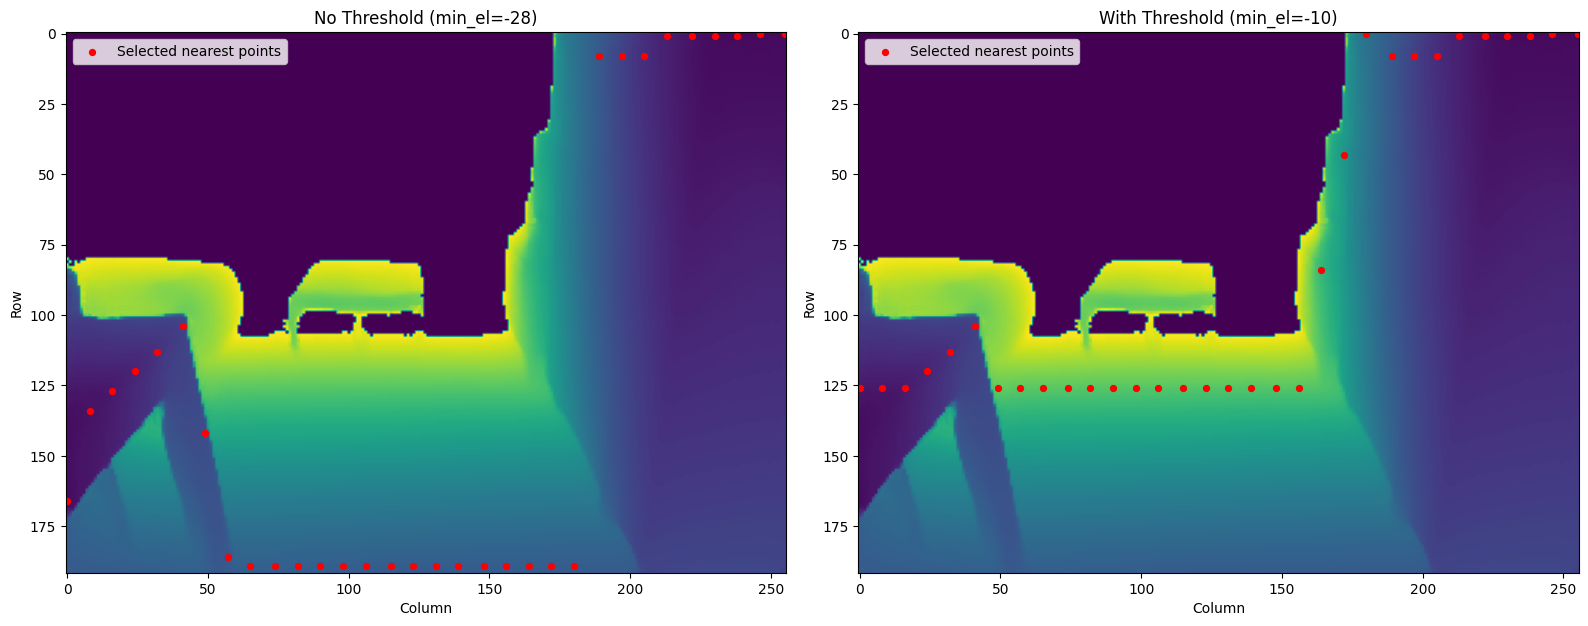

In [21]:
d = depths[0]

mn = np.nanmin(d)
mx = np.nanmax(d)

if np.isclose(mn, mx):
    disp = np.zeros_like(d, dtype=np.uint8)
else:
    disp = np.interp(d, (mn, mx), (0, 255)).astype(np.uint8)

near_az, near_el, near_dist, sel_cols, sel_rows = extract_scan_points(
    d, min_elevation_deg=-28 # -28° approximates the lower limit of the sensor's elevation range.
) # No threshold 

near_az1, near_el1, near_dist1, sel_cols1, sel_rows1 = extract_scan_points(
    d, min_elevation_deg=-10
) # With threshold (Feel free to tweak)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Without threshold
axes[0].imshow(disp, cmap="viridis", origin="upper")
axes[0].scatter(sel_cols, sel_rows, c="red", s=18, label="Selected nearest points")
axes[0].set_title("No Threshold (min_el=-28)")
axes[0].set_xlabel("Column")
axes[0].set_ylabel("Row")
axes[0].legend()

# Plot 2: With threshold
axes[1].imshow(disp, cmap="viridis", origin="upper")
axes[1].scatter(sel_cols1, sel_rows1, c="red", s=18, label="Selected nearest points")
axes[1].set_title("With Threshold (min_el=-10)")
axes[1].set_xlabel("Column")
axes[1].set_ylabel("Row")
axes[1].legend()

plt.tight_layout()
plt.show()

### Sweep-based sonification

The extracted scan points are converted into a time-based audio sweep.

For each scan position:
- a short audio ping is generated
- the ping is spatialized using HRTF (azimuth + elevation)
- the loudness is scaled based on distance
- the ping is placed at a specific time in the sweep

The result is a sequence of spatial audio cues moving from left to right across the field of view.

In [22]:
def build_sweep_hrtf(near_az, near_el, near_dist, sofa, 
                     tree, reverse=False, max_range=3.0,
                     sample_rate=48000, sweep_duration=2.0,
                     ping_dur=0.18):
    
    W = len(near_az)
    total_samples = int(sample_rate * sweep_duration)
    stereo = np.zeros((total_samples, 2), dtype=np.float32)

    if reverse:
        idx_range = range(W - 1, -1, -1)
    else: 
        idx_range = range(W)

    for out_i, i in enumerate(idx_range):
        if W == 1:
            t_center = sweep_duration / 2
        else:
            t_center = (out_i / (W - 1)) * sweep_duration

        s_start = max(int((t_center - ping_dur / 2) * sample_rate), 0)

        d = float(np.clip(near_dist[i], 0.0, max_range))

        ping = make_spatial_ping(azimuth=near_az[i],elevation=near_el[i],distance=d,
                                 sofa=sofa,tree=tree,sample_rate=sample_rate,
                                 max_range=max_range,dur=ping_dur)
        
        n = ping.shape[0]
        s_end = min(s_start + n, total_samples)
        n_write = s_end - s_start

        if n_write > 0:
            stereo[s_start:s_end] += ping[:n_write]

    peak = np.abs(stereo).max()
    if peak > 0:
        stereo /= peak

    return stereo

#### Listening test: forward and backward sweep

The following demonstrates the sweep-based sonification.

When listening with headphones:
- sounds move from left to right across the field of view
- closer objects appear louder
- elevation cues are present through HRTF spatialization

In [23]:
sweep_fwd = build_sweep_hrtf(
    near_az, near_el, near_dist,
    sofa=SOFA,
    tree=tree,
    reverse=False
)

sweep_bwd = build_sweep_hrtf(
    near_az, near_el, near_dist,
    sofa=SOFA,
    tree=tree,
    reverse=True
)

sd.play(sweep_fwd, 48000)
sd.wait()

sd.play(sweep_bwd, 48000)
sd.wait()

### Visual aid during sweep playback

To make the sweep easier to interpret, a synchronized visualization is shown during playback.

This function uses IPython display utilities to render a frame-synchronised visualisation during audio playback."

In [24]:
from IPython.display import display, clear_output

def play_sweep_with_inline_visual(d, sel_cols, sel_rows, near_az, 
                                  near_dist, sweep_audio, sample_rate=48000, 
                                  sweep_duration=4.0, reverse=False, fps=20):
    
    display_depth = d.copy()
    finite = np.isfinite(display_depth)
    mx = np.percentile(display_depth[finite], 95) if np.any(finite) else 1.0
    display_depth[~finite] = mx

    W = len(sel_cols)
    if W == 0:
        print("No scan points to display.")
        return

    sd.play(sweep_audio, samplerate=sample_rate)
    t0 = time.perf_counter()

    while True:
        elapsed = time.perf_counter() - t0
        frac = min(elapsed / sweep_duration, 1.0)

        idx = int(round(frac * (W - 1)))
        idx = np.clip(idx, 0, W - 1)

        if reverse:
            idx = (W - 1) - idx

        u = sel_cols[idx]
        v = sel_rows[idx]
        az = near_az[idx]
        dist = near_dist[idx]

        fig, (ax_img, ax_prof) = plt.subplots(2, 1, figsize=(8, 7))
        fig.suptitle("Sweep Visualization")

        # top panel
        im = ax_img.imshow(display_depth, cmap="viridis", origin="upper")
        ax_img.scatter(sel_cols, sel_rows, c="red", s=20)
        ax_img.axvline(u, color="white", linestyle="--", linewidth=1.5)
        ax_img.plot([u], [v], "wo", markersize=8)
        ax_img.set_title("Depth Frame")
        ax_img.set_xlabel("Column")
        ax_img.set_ylabel("Row")

        # bottom panel
        ax_prof.plot(near_az, near_dist, linewidth=1.5)
        ax_prof.axvline(az, color="tomato", linestyle="--", linewidth=1.5)
        ax_prof.plot([az], [dist], "ro")
        ax_prof.set_title("Nearest Distance vs Azimuth")
        ax_prof.set_xlabel("Azimuth (deg)")
        ax_prof.set_ylabel("Distance (m)")
        ax_prof.grid(True)

        plt.tight_layout()

        clear_output(wait=True)
        display(fig)
        plt.close(fig)

        if elapsed >= sweep_duration:
            break

        time.sleep(1.0 / fps)

    sd.wait()

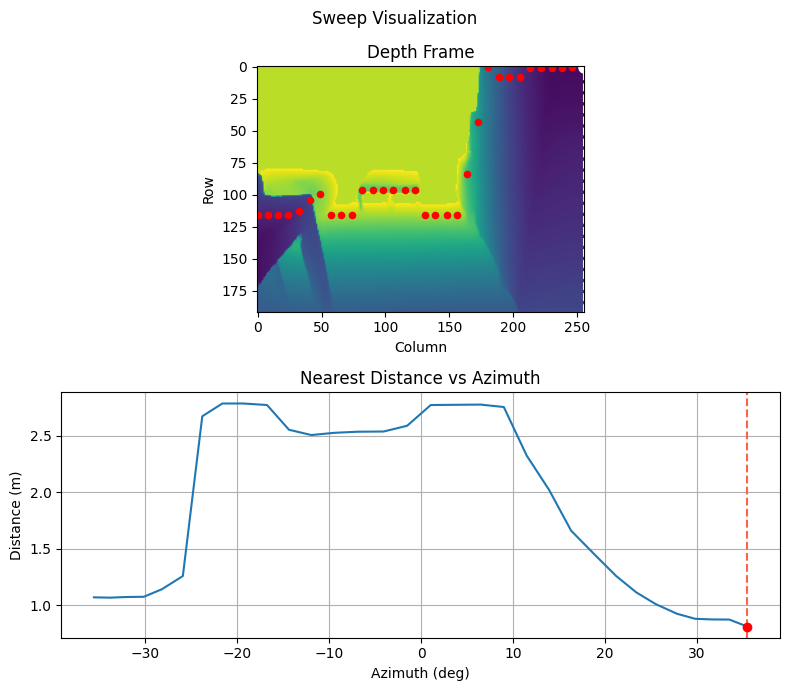

In [25]:
d = depths[0]

near_az, near_el, near_dist, sel_cols, sel_rows = extract_scan_points(
    d, min_elevation_deg=-7.0
)

sweep_fwd = build_sweep_hrtf(
    near_az, near_el, near_dist,
    sofa=SOFA,
    tree=tree,
    reverse=False,
    sweep_duration=4.0
)

play_sweep_with_inline_visual(
    d=d,
    sel_cols=sel_cols,
    sel_rows=sel_rows,
    near_az=near_az,
    near_dist=near_dist,
    sweep_audio=sweep_fwd,
    sample_rate=48000,
    sweep_duration=4.0,
    reverse=False,
    fps=15,
)

## 6. Frame-by-frame depth playback with sweep overlay

This section demonstrates a prototype integration of:
- recorded depth video
- sweep-based spatial sonification

For each depth frame:
1. the frame is displayed
2. a full forward sweep is played
3. a full backward sweep is played
4. the next frame is then processed

This is a simplified prototype design intended to clearly show the relationship between a single depth frame and its corresponding audio sweep.

In a future real-time version, depth updates and sweep generation should occur concurrently rather than sequentially. That will likely require multithreading or a similar asynchronous processing structure.

In [26]:
def play_depth_video_with_sweeps(depths, n_frames, sofa, tree, 
                                 max_range=6.0, min_elevation_deg=-10.0, 
                                 sample_rate=48000, sweep_duration=4.0, 
                                 ping_dur=0.04, max_frames=None, 
                                 frame_step = 10):
    
    if max_frames is not None:
        n_frames = min(n_frames, max_frames)

    for i in range(0, n_frames, frame_step):
        d = depths[i]

        # display image
        mn = np.nanmin(d)
        mx = np.nanmax(d)

        if np.isclose(mn, mx):
            disp = np.zeros_like(d, dtype=np.uint8)
        else:
            disp = np.interp(d, (mn, mx), (0, 255)).astype(np.uint8)

        disp = cv2.resize(disp, (512, 256))
        d_color = cv2.applyColorMap(disp, cv2.COLORMAP_VIRIDIS)

        # extract scan points from original depth frame
        near_az, near_el, near_dist, sel_cols, sel_rows = extract_scan_points(
            d,
            max_range=max_range,
            min_elevation_deg=min_elevation_deg
        )

        if len(near_az) == 0:
            cv2.imshow("Depth + Sweep", d_color)
            print(f"Frame {i}: no valid scan points found.")
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
            continue

        # scale selected points to resized display
        h0, w0 = d.shape
        h1, w1 = disp.shape

        sel_cols_vis = (sel_cols * (w1 / w0)).astype(int)
        sel_rows_vis = (sel_rows * (h1 / h0)).astype(int)

        # forward sweep
        sweep_fwd = build_sweep_hrtf(
            near_az, near_el, near_dist,
            sofa=sofa,
            tree=tree,
            reverse=False,
            max_range=max_range,
            sample_rate=sample_rate,
            sweep_duration=sweep_duration,
            ping_dur=ping_dur,
        )

        # show frame before sweep
        frame_vis = d_color.copy()
        for u, v in zip(sel_cols_vis, sel_rows_vis):
            cv2.circle(frame_vis, (u, v), 2, (0, 0, 255), -1)

        cv2.putText(frame_vis, f"Frame {i} - Forward Sweep", (10, 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)

        cv2.imshow("Depth + Sweep", frame_vis)
        cv2.waitKey(1)

        sd.play(sweep_fwd, samplerate=sample_rate)
        t0 = time.perf_counter()

        while True:
            elapsed = time.perf_counter() - t0
            frac = min(elapsed / sweep_duration, 1.0)

            idx = int(round(frac * (len(sel_cols_vis) - 1)))
            idx = np.clip(idx, 0, len(sel_cols_vis) - 1)

            vis = frame_vis.copy()
            u = sel_cols_vis[idx]
            v = sel_rows_vis[idx]

            cv2.line(vis, (u, 0), (u, h1 - 1), (255, 255, 255), 1)
            cv2.circle(vis, (u, v), 5, (255, 255, 255), -1)

            cv2.imshow("Depth + Sweep", vis)

            if cv2.waitKey(1) & 0xFF == ord('q'):
                sd.stop()
                cv2.destroyWindow("Depth + Sweep")
                return

            if elapsed >= sweep_duration:
                break

        sd.wait()

        # backward sweep
        sweep_bwd = build_sweep_hrtf(
            near_az, near_el, near_dist,
            sofa=sofa,
            tree=tree,
            reverse=True,
            max_range=max_range,
            sample_rate=sample_rate,
            sweep_duration=sweep_duration,
            ping_dur=ping_dur,
        )

        frame_vis = d_color.copy()
        for u, v in zip(sel_cols_vis, sel_rows_vis):
            cv2.circle(frame_vis, (u, v), 2, (0, 0, 255), -1)

        cv2.putText(frame_vis, f"Frame {i} - Backward Sweep", (10, 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)

        cv2.imshow("Depth + Sweep", frame_vis)
        cv2.waitKey(1)

        sd.play(sweep_bwd, samplerate=sample_rate)
        t0 = time.perf_counter()

        while True:
            elapsed = time.perf_counter() - t0
            frac = min(elapsed / sweep_duration, 1.0)

            idx = int(round(frac * (len(sel_cols_vis) - 1)))
            idx = np.clip(idx, 0, len(sel_cols_vis) - 1)
            idx = (len(sel_cols_vis) - 1) - idx

            vis = frame_vis.copy()
            u = sel_cols_vis[idx]
            v = sel_rows_vis[idx]

            cv2.line(vis, (u, 0), (u, h1 - 1), (255, 255, 255), 1)
            cv2.circle(vis, (u, v), 5, (255, 255, 255), -1)

            cv2.imshow("Depth + Sweep", vis)

            if cv2.waitKey(1) & 0xFF == ord('q'):
                sd.stop()
                cv2.destroyWindow("Depth + Sweep")
                return

            if elapsed >= sweep_duration:
                break

        sd.wait()

    cv2.destroyWindow("Depth + Sweep")

In [27]:
play_depth_video_with_sweeps(
    depths=depths,
    n_frames=frames,
    sofa=SOFA,
    tree=tree,
    max_range=6.0,
    min_elevation_deg=-12.0,
    sample_rate=48000,
    sweep_duration=2,
    ping_dur=0.18,
    max_frames=1000,
    frame_step = 100
)

C:\Users\ahmad\AppData\Local\Temp\ipykernel_17352\2544316947.py:20: RuntimeWarning: invalid value encountered in cast
  disp = np.interp(d, (mn, mx), (0, 255)).astype(np.uint8)


#### Limitation

In this prototype, each frame is held fixed while a full forward and backward sweep is completed.

This makes the mapping between one frame and one sweep easy to inspect, but it is not yet real-time.

In a future real-time system:
- new depth frames should continue arriving while the sweep is being played
- audio generation and visual/depth updates should run concurrently
- this will likely require threading or another asynchronous design

## 7. Semi Real-time depth sonification

This section brings together everything from the previous sections into a semi-real-time simulation.

The goal is to simulate real-time recording while sonification is happening continuously. Depth frames play at 60 fps, and an audio sweep runs independently, always reading from whatever frame is currently on screen.

### Design overview

Two threads run concurrently:

**Video thread** — Advances through depth frames at 60 fps. Each frame is colorized and displayed. It writes the current frame index into a small shared state dictionary so the audio thread always knows which frame is on screen.

**Audio thread** — Runs an infinite sweep loop. At the start of each new sweep it reads the current frame index from shared state, builds a full stereo sweep buffer for that frame using `build_sweep_hrtf`, and plays it. While that sweep is playing it immediately starts building the next one in a background thread so it is ready before the current one ends. When the two sweeps meet, a short crossfade blends them together so the transition is seamless. The direction alternates forward → backward → forward on every sweep.

### Shared state

The two threads share only a small dictionary protected by a lock:

```
state = {
    "current_frame_idx"  — written by video thread, read by audio thread
    "running"            — set to False when video ends or user presses Q
    "sweep_start_time"   — written by audio thread so video thread can draw the sweep line
    "sweep_duration"     — written by audio thread
    "sweep_direction"    — written by audio thread (+1 forward, -1 backward)
}
```

The video thread uses `sweep_start_time`, `sweep_duration`, and `sweep_direction` to compute where the sweep line should be drawn each frame, without needing to talk to the audio thread directly.

### Step 1 — Precompute scan data

Scan points (azimuth, elevation, distance) are extracted for every frame ahead of time. This is the same `precompute_scan_data` function used in section 8. It only needs to be run once then the result is reused across all simulations.

In [28]:
def precompute_scan_data(
    depths,
    n_frames,
    max_range=6.0,
    min_elevation_deg=-10.0,
    scan_cols=None
):
    all_scan_data = []

    for i in range(n_frames):
        d = depths[i]

        near_az, near_el, near_dist, sel_cols, sel_rows = extract_scan_points(
            d,
            scan_cols=scan_cols,
            max_range=max_range,
            min_elevation_deg=min_elevation_deg
        )

        all_scan_data.append({
            "near_az": near_az,
            "near_el": near_el,
            "near_dist": near_dist,
            "sel_cols": sel_cols,
            "sel_rows": sel_rows
        })

        if i % 100 == 0:
            print(f"Precomputed frame {i}/{n_frames}")

    return all_scan_data

In [29]:
scan_cols = np.linspace(0, depths[0].shape[1] - 1, 32, dtype=int)

all_scan_data = precompute_scan_data(
    depths=depths,
    n_frames=frames,
    max_range=6.0,
    min_elevation_deg=-15.0,
    scan_cols=scan_cols
)

Precomputed frame 0/1849
Precomputed frame 100/1849
Precomputed frame 200/1849
Precomputed frame 300/1849
Precomputed frame 400/1849
Precomputed frame 500/1849
Precomputed frame 600/1849
Precomputed frame 700/1849
Precomputed frame 800/1849
Precomputed frame 900/1849
Precomputed frame 1000/1849
Precomputed frame 1100/1849
Precomputed frame 1200/1849
Precomputed frame 1300/1849
Precomputed frame 1400/1849
Precomputed frame 1500/1849
Precomputed frame 1600/1849
Precomputed frame 1700/1849
Precomputed frame 1800/1849


### Step 2 — Shared state

A small dictionary is shared between threads. The lock ensures neither thread reads half-written values.

In [30]:
state = {
    "current_frame_idx": 0,
    "running": True,
    "sweep_start_time": time.perf_counter(),
    "sweep_duration": 2.0,
    "sweep_direction": 1,
}
state_lock = threading.Lock()

### Step 3 — Video thread

Advances through every depth frame at the target fps. Each iteration:
1. writes the current frame index to shared state
2. colorizes the depth frame
3. draws the scan point dots
4. reads sweep timing from shared state and computes the sweep line position
5. draws the sweep line and displays the frame
6. sleeps for the remainder of the frame budget

The sweep line position is computed purely from elapsed time leaving no need for communication with the audio thread beyond reading three numbers from shared state.

In [31]:
def video_loop(depths, n_frames, all_scan_data, state, state_lock, fps=60.0):
    frame_time = 1.0 / fps

    for i in range(n_frames):
        frame_start = time.perf_counter()

        with state_lock:
            if not state["running"]:
                break
            state["current_frame_idx"] = i
            sweep_start = state["sweep_start_time"]
            sweep_dur = state["sweep_duration"]
            sweep_dir = state["sweep_direction"]

        d = depths[i]
        mn, mx = np.nanmin(d), np.nanmax(d)
        disp = np.zeros_like(d, dtype=np.uint8) if np.isclose(mn, mx) else \
               np.interp(d, (mn, mx), (0, 255)).astype(np.uint8)
        disp = cv2.resize(disp, (512, 256))
        d_color = cv2.applyColorMap(disp, cv2.COLORMAP_VIRIDIS)

        scan = all_scan_data[i]
        sel_cols, sel_rows = scan["sel_cols"], scan["sel_rows"]
        h0, w0 = d.shape
        h1, w1 = disp.shape

        if len(sel_cols) > 0:
            sel_cols_vis = (sel_cols * (w1 / w0)).astype(int)
            sel_rows_vis = (sel_rows * (h1 / h0)).astype(int)

            for u, v in zip(sel_cols_vis, sel_rows_vis):
                cv2.circle(d_color, (u, v), 1, (0, 0, 255), -1)

            # compute sweep line position
            elapsed = time.perf_counter() - sweep_start
            frac = float(np.clip(elapsed / sweep_dur, 0.0, 1.0))
            if sweep_dir == -1:
                frac = 1.0 - frac

            idx = int(round(frac * (len(sel_cols_vis) - 1)))
            idx = int(np.clip(idx, 0, len(sel_cols_vis) - 1))

            u = sel_cols_vis[idx]
            v = sel_rows_vis[idx]
            cv2.line(d_color, (u, 0), (u, h1 - 1), (255, 255, 255), 1)
            cv2.circle(d_color, (u, v), 5, (255, 255, 255), -1)

        sweep_txt = "Forward" if sweep_dir == 1 else "Backward"
        cv2.putText(d_color, f"Frame {i} - {sweep_txt}", (10, 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1, cv2.LINE_AA)
        cv2.imshow("Realtime Depth Sonification", d_color)

        elapsed = time.perf_counter() - frame_start
        remaining = max(1, int((frame_time - elapsed) * 1000))
        if cv2.waitKey(remaining) & 0xFF == ord('q'):
            with state_lock:
                state["running"] = False
            break

    with state_lock:
        state["running"] = False
    cv2.destroyWindow("Realtime Depth Sonification")

### Step 4 — Audio thread

Runs a continuous sweep loop with crossfading between sweeps.

**Each iteration:**
1. Reads the current frame index and builds the current sweep (if first iteration) or uses the pre-built one from the previous iteration
2. Immediately kicks off a background thread to pre-build the next sweep while the current one plays
3. Plays the current sweep through a persistent `OutputStream` whose callback mixes the outgoing and incoming buffers during the crossfade window
4. Waits until the crossfade is complete, then promotes the next sweep to current and flips direction

**The callback** is the heart of the crossfade. It runs on the audio hardware thread every ~10ms (512 samples at 48kHz). It tracks two states:
- **Plain playback** (`cf_pos == -1`): copies samples from the current buffer directly to output
- **Crossfade** (`cf_pos >= 0`): mixes current (fading out with cos²) and next (fading in with sin²) until `cf_pos` reaches `cf_samples` or the current buffer is exhausted, whichever comes first, then promotes next → current

The cos²/sin² pair is a standard equal-power crossfade: at any point during the fade `cos²(t) + sin²(t) = 1`, so the total loudness stays constant and there is no audible dip.

In [32]:
def audio_loop(all_scan_data, sofa, tree, state, state_lock,
               sample_rate=48000, sweep_duration=2.0, ping_dur=0.18,
               max_range=6.0):

    CROSSFADE = 0.2
    cf_samples = int(CROSSFADE * sample_rate)

    def build_sweep(frame_idx, reverse):
        scan = all_scan_data[frame_idx]
        near_az, near_el, near_dist = scan["near_az"], scan["near_el"], scan["near_dist"]
        if len(near_az) == 0:
            return None
        return build_sweep_hrtf(
            near_az, near_el, near_dist,
            sofa=sofa, tree=tree, reverse=reverse,
            max_range=max_range, sample_rate=sample_rate,
            sweep_duration=sweep_duration, ping_dur=ping_dur,
        )

    cb = {
        "current":   None,
        "next":      None,
        "pos":       0,
        "cf_pos":    -1,
        "promoted":  False,   # callback sets this True when next becomes current
        "direction": 1,       # callback owns direction, flips on promotion
    }
    cb_lock = threading.Lock()

    def callback(outdata, frames, time_info, status):
        with cb_lock:
            out = np.zeros((frames, 2), dtype=np.float32)
            cur  = cb["current"]
            nxt  = cb["next"]
            pos  = cb["pos"]
            cf_p = cb["cf_pos"]
    
            if cur is None:
                outdata[:] = out
                return
    
            remaining = len(cur) - pos
    
            # trigger crossfade when close to end and next is ready
            if nxt is not None and cf_p == -1 and remaining <= cf_samples:
                cb["cf_pos"] = 0
                cf_p = 0
    
            if cf_p == -1:
                n = min(frames, remaining)
                out[:n] = cur[pos:pos + n]
                cb["pos"] = pos + n
                # current exhausted with no crossfade = silence guard
                if cb["pos"] >= len(cur) and nxt is None:
                    cb["current"] = None
            else:
                # crossfade: only consume as many samples as BOTH buffers have
                n_cur = max(len(cur) - pos, 0)       # samples left in current
                n_nxt = max(len(nxt) - cf_p, 0)      # samples left in next (reading from cf_p)
                n = min(frames, max(n_cur, n_nxt))   # run until the longer one ends
    
                if n > 0:
                    t_arr = np.linspace(cf_p, cf_p + n - 1, n) / cf_samples
                    t_arr = np.clip(t_arr, 0.0, 1.0)
                    fade_out = (np.cos(t_arr * np.pi / 2) ** 2).reshape(-1, 1)
                    fade_in  = (np.sin(t_arr * np.pi / 2) ** 2).reshape(-1, 1)
    
                    cur_chunk = np.zeros((n, 2), dtype=np.float32)
                    nxt_chunk = np.zeros((n, 2), dtype=np.float32)
    
                    if n_cur > 0:
                        take = min(n, n_cur)
                        cur_chunk[:take] = cur[pos:pos + take]
                    if n_nxt > 0:
                        take = min(n, n_nxt)
                        nxt_chunk[:take] = nxt[cf_p:cf_p + take]
    
                    out[:n] = cur_chunk * fade_out + nxt_chunk * fade_in
    
                cb["cf_pos"] = cf_p + n
                cb["pos"]    = pos  + n
    
                # promote whenever crossfade is done OR current is exhausted
                if cb["cf_pos"] >= cf_samples or cb["pos"] >= len(cur):
                    cb["current"]   = nxt
                    cb["next"]      = None
                    cb["pos"]       = cb["cf_pos"]   # continue from where we are in next
                    cb["cf_pos"]    = -1
                    cb["direction"] *= -1
                    cb["promoted"]  = True
    
            outdata[:] = out

    stream = sd.OutputStream(
        samplerate=sample_rate, channels=2,
        dtype="float32", blocksize=512,
        callback=callback
    )
    stream.start()

    # load first sweep
    with state_lock:
        frame_idx = state["current_frame_idx"]
    first = build_sweep(frame_idx, reverse=False)
    with cb_lock:
        cb["current"] = first
        cb["pos"]     = 0

    with state_lock:
        state["sweep_start_time"] = time.perf_counter()
        state["sweep_duration"]   = sweep_duration
        state["sweep_direction"]  = 1

    next_queued = False   # has the next sweep been queued for the current playback?

    while True:
        with state_lock:
            if not state["running"]:
                break
            frame_idx = state["current_frame_idx"]

        with cb_lock:
            cur      = cb["current"]
            pos      = cb["pos"]
            promoted = cb["promoted"]
            direction = cb["direction"]
            has_next = cb["next"] is not None

        # when callback signals a promotion, reset our queued flag
        # and update the visual sweep state
        if promoted:
            with cb_lock:
                cb["promoted"] = False
            next_queued = False
            with state_lock:
                state["sweep_start_time"] = time.perf_counter()
                state["sweep_duration"]   = sweep_duration
                state["sweep_direction"]  = direction

        # build and queue next sweep when we're close enough to the end
        if cur is not None and not next_queued and not has_next:
            remaining_s = (len(cur) - pos) / sample_rate
            if remaining_s < CROSSFADE + 0.4:
                next_sweep = build_sweep(frame_idx, reverse=(direction == 1))
                if next_sweep is not None:
                    with cb_lock:
                        cb["next"] = next_sweep
                next_queued = True

        time.sleep(0.02)

    stream.stop()
    stream.close()

### Step 5 — Run

Launches both threads and waits for them to finish. Press **Q** in the video window to stop.

Parameters to tune:
- `sweep_duration` — how long one left-to-right (or right-to-left) sweep takes in seconds
- `ping_dur` — duration of each individual spatial ping; should be ≥ `sweep_duration / n_scan_cols` for continuous sound
- `crossfade` — overlap between consecutive sweeps in seconds; 0.2–0.4 works well
- `fps` — video playback rate

In [33]:
def run_realtime_simulation(
    depths,
    n_frames,
    all_scan_data,
    sofa,
    tree,
    fps=60.0,
    sample_rate=48000,
    sweep_duration=2.0,
    ping_dur=0.18,
    max_range=6.0,
):
    with state_lock:
        state["current_frame_idx"] = 0
        state["running"] = True

    video_thread = threading.Thread(
        target=video_loop,
        args=(depths, n_frames, all_scan_data, state, state_lock, fps),
        daemon=True
    )
    audio_thread = threading.Thread(
        target=audio_loop,
        args=(all_scan_data, sofa, tree, state, state_lock,
              sample_rate, sweep_duration, ping_dur, max_range),
        daemon=True
    )

    video_thread.start()
    audio_thread.start()

    video_thread.join()
    audio_thread.join()

#### Testing

You can test the player with this and feel free to tweak the settings for different results

In [34]:
scan_cols = np.linspace(0, depths[0].shape[1] - 1, 32, dtype=int)

run_realtime_simulation(
    depths=depths,
    n_frames=frames,
    all_scan_data=all_scan_data,
    sofa=SOFA,
    tree=tree,
    fps=60.0,
    sample_rate=48000,
    sweep_duration=2.0,   # same as the working frame-by-frame call
    ping_dur=0.18,        # same as the working frame-by-frame call
    max_range=6.0,
)

C:\Users\ahmad\AppData\Local\Temp\ipykernel_17352\1833550782.py:18: RuntimeWarning: invalid value encountered in cast
  np.interp(d, (mn, mx), (0, 255)).astype(np.uint8)


## 8. Next steps: dynamic hazard tracking and extended FOV coverage

This final section outlines the next development steps that will be taken to address the current limitations of the LiDAR sonification pipeline.

The two main limitations of the current system are:

- limited LiDAR field of view
- difficulty emphasizing fast-moving hazards within the sweep

While the continuous sweep provides strong spatial awareness, it is not ideal for urgent dynamic hazards that may approach quickly or enter between sweeps.

For this reason, the next stage of development will introduce a second hazard-awareness pipeline on top of the existing sweep system.

### LiDAR-based dynamic hazard tracking

The first major next step is to implement dynamic object clustering and motion estimation directly from the LiDAR depth stream.

The goal of this pipeline is to detect moving objects within the LiDAR field of view and estimate their relative motion in the sensor frame.

This will allow the system to generate an additional click-based warning channel for potentially approaching hazards.

The current idea is to cluster LiDAR points into object groups across consecutive frames and track their centroids over time.

A filtering / tracking method such as a `Kalman filter` can then be used to smooth the trajectories and estimate relative motion.

This will provide a much more reliable urgency estimate than using RGB bounding box displacement alone.

The ideal implementation is to build this tracking pipeline directly inside the native LiDAR application rather than performing all processing in Python.

This would allow the depth frames and derived tracking outputs to be processed closer to the sensor stream and reduce the computational load on the Python prototyping environment.

The intention is to send the tracked-object information as metadata alongside the depth stream.

This metadata may include:

- tracked object ID
- object centroid position
- relative motion estimate
- approximate approach urgency
- timestamp / frame index

Since this mainly involves algorithm implementation on top of already available depth data, it should be feasible to implement natively without significant overhead.

Python can then focus mainly on the sonification and visualization layers.

### Extended FOV hazard awareness

The second next step is to address the field-of-view limitation of the LiDAR system.

Since the LiDAR FOV is restricted to approximately `[-35°, 35°]` horizontally, moving hazards may still enter from outside the directly scanned region.

To address this, an additional RGB-based object detection layer will be added on top of the LiDAR pipeline.

The current idea is to use YOLO only as a peripheral hazard detector outside the LiDAR field of view.

This avoids overloading the system with dense full-frame detection while still allowing dynamic objects entering from the sides to be detected.

For objects outside the LiDAR region, bounding box growth and persistence across frames can be used as approximate urgency cues.

This layer is not intended for precise velocity estimation.

Instead, it acts as an early warning system for hazards approaching from outside the main sweep region.

### Final system idea

The final pipeline is currently planned as three parallel branches:

**Continuous LiDAR sweep** — provides constant spatial depth awareness

**LiDAR motion tracking** — provides click-based urgent hazard warnings inside the LiDAR FOV

**YOLO peripheral detection** — provides side-entry hazard alerts outside the LiDAR FOV

This layered approach aims to combine continuous environmental awareness with stronger dynamic hazard detection.

### Questions

The following are the main design questions we would like feedback on before moving into the next implementation stage.

1. Does the proposed three-branch pipeline architecture make sense from a system design perspective?

2. Would implementing the LiDAR clustering and motion-tracking pipeline natively inside the mobile application be the preferred approach, or should more of this processing remain in Python during prototyping? If so, do you think we should attempt to build the entire application natively, or continue keeping the main processing and sonification pipeline in Python for now?

3. For dynamic hazard tracking, would a `Kalman filter` be an appropriate first approach, or would another tracking method be more suitable? This is a relatively new area for us, so we would appreciate guidance on whether this is the right direction.

4. How should ego-motion of the user be accounted for when estimating object motion from LiDAR clusters?

5. For hazards outside the LiDAR FOV, is a YOLO-based peripheral detection layer a reasonable solution, or do you have another method in mind that may be preferable?

   **Note:** One possible alternative idea is to use monocular depth estimation methods exclusively for regions outside of the iPhone LiDAR FOV. However, we are currently unsure about the latency, computational load, and depth accuracy of such an approach.

6. From a usability perspective, does the separation between continuous sweep audio and click-based hazard alerts seem intuitive?

7. Are there additional risks or limitations in the current architecture that should be addressed before implementation?

8. Given the current project direction and the planned future features (such as hazard reporting, map integration, and tracked object metadata), what type of database would you recommend using at this stage? Would a relational database be more suitable, or would a NoSQL solution better fit the expected data structure and future scalability?

In addition to the technical feedback above, we would also like to ask for your assistance regarding access to the Mac laboratory facilities.

At this stage of the project, access to macOS hardware has become increasingly important for native iOS and LiDAR-based application development. Unfortunately, despite multiple attempts on our end, we have not been able to secure access. We have already spoken with the head of the department, submitted a formal petition, and reached out to the laboratory assistants, but so far no one has been able to help us.

We are beginning to reach a critical point where the lack of access is significantly affecting our ability to continue implementation and testing, and we are becoming quite concerned about the project timeline.

If possible, we would be extremely grateful if you could assist us by leveraging your position within the university to help us gain access to the Mac labs or direct us to someone who may be able to authorize this. At this point, we have exhausted the avenues available to us and would sincerely appreciate any support or guidance you may be able to provide.